The EDA and feature engineering are done. Now we need to figure out which features actually matter before we hand anything to a model. Not everything we built will be useful, some features will be redundant, some will just add noise. This section is about trimming that down to a clean, meaningful set that gives the model the best chance of learning something real.

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

###**Load The Data**

In [2]:
df = pd.read_csv("features.csv")
df.head()

,log_Recency,log_Frequency,log_Monetary,log_avg_order_value,log_avg_days_between_orders,log_tenure_days,log_return_rate,log_unique_products,log_unique_months_active,log_last_month_revenue,log_ltv_3m,Customer ID
0,4.158883,2.484907,5.923881,2.509501,1.945910,5.560682,0.223144,3.295837,1.609438,0.0,0.000000,12346
1,4.653960,1.098612,7.146394,3.331840,0.330242,4.820282,0.091808,3.871201,1.098612,0.0,7.246810,12349
2,4.624973,0.693147,6.192792,3.143780,0.000000,4.624973,0.000000,3.135494,0.693147,0.0,0.000000,12355
3,4.442651,1.098612,7.437754,3.902221,1.844278,5.583496,0.000000,3.555348,1.098612,0.0,6.929595,12358
4,4.248495,1.791759,7.607396,3.194407,1.199256,5.594711,0.043485,4.418841,1.386294,0.0,6.314146,12359


In [3]:
df.columns

Index(['log_Recency', 'log_Frequency', 'log_Monetary', 'log_avg_order_value',
       'log_avg_days_between_orders', 'log_tenure_days', 'log_return_rate',
       'log_unique_products', 'log_unique_months_active',
       'log_last_month_revenue', 'log_ltv_3m', 'Customer ID'],
      dtype='object')

In [4]:
# Separate features and target
feature_cols = [
    'log_Recency', 'log_Frequency', 'log_Monetary',
    'log_avg_order_value', 'log_avg_days_between_orders',
    'log_tenure_days', 'log_return_rate', 'log_unique_products',
    'log_unique_months_active', 'log_last_month_revenue'
]

target_cols = "log_ltv_3m"

In [5]:
X = df[feature_cols]
y = df[target_cols]

print(f"Shape: {df.shape}")
print(f"Nulls: {df.isnull().sum().sum()}")
print(f"Features: {len(feature_cols)}")

Shape: (3313, 12)
Nulls: 0
Features: 10


### **Correlation Matrix**

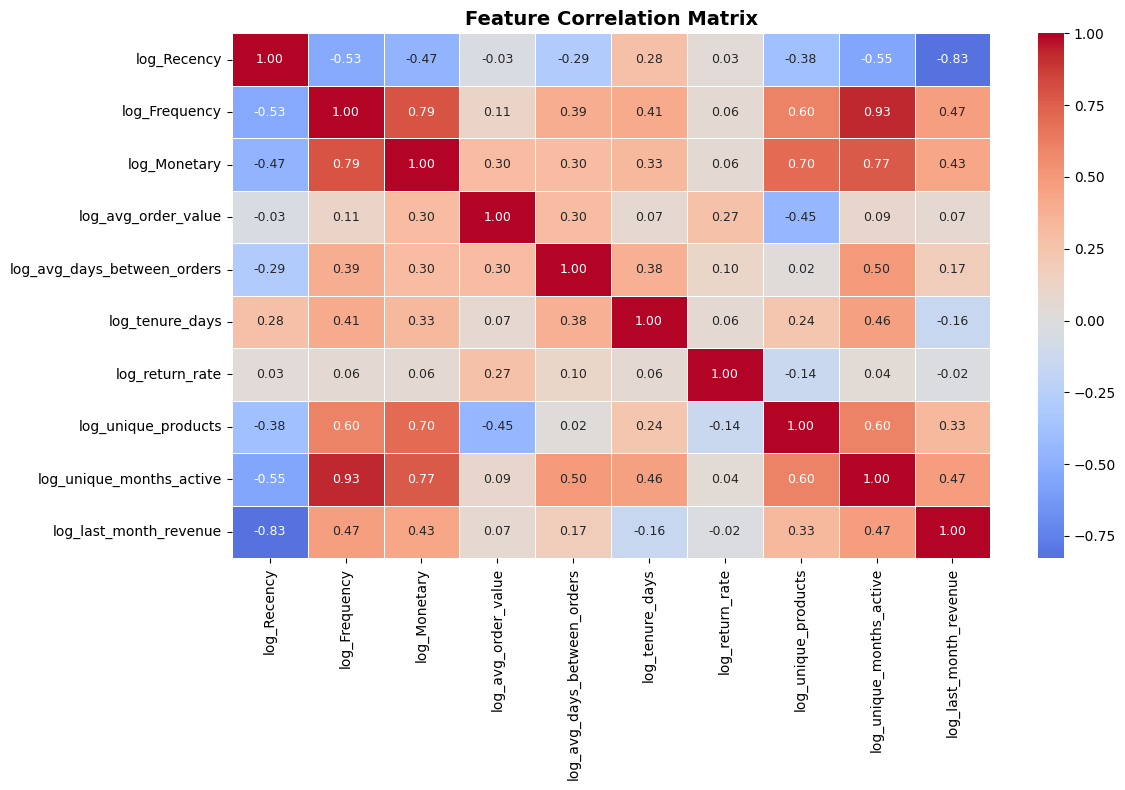

In [6]:
plt.figure(figsize=(12,8))
corr_matrix = X.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0,
    linewidths=0.5,
    annot_kws={"size":9}
)
plt.title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [7]:
# Highly correlated pairs
found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = abs(corr_matrix.iloc[i,j])
        if val > 0.85:
            print(f" {corr_matrix.columns[i]} vs {corr_matrix.columns[j]}: {val:.2f}")
            found = True
if not found:
    print("None feature found above 0.85 threshold")

 log_Frequency vs log_unique_months_active: 0.93


Log_frequency and log_unique_months_active are highly correlated at 0.93. Customers who buys often show up across months. We won't drop anything here yet until we see how each feature correlate with the target and what mutual information score says

### **Correlation With Target**

In [8]:
target_corr = X.corrwith(y).abs().sort_values(ascending=False).reset_index()
target_corr

,index,0
0,log_unique_months_active,0.468120
1,log_Monetary,0.461743
2,log_Frequency,0.456607
3,log_unique_products,0.387137
4,log_Recency,0.310237
5,log_last_month_revenue,0.265099
6,log_avg_days_between_orders,0.180854
7,log_tenure_days,0.147384
8,log_avg_order_value,0.035427
9,log_return_rate,0.001931


In [9]:
target_corr.columns = ["Feature", "Correlation with Target"]
target_corr["Correlation with Target"] = target_corr["Correlation with Target"].round(3)
target_corr

,Feature,Correlation with Target
0,log_unique_months_active,0.468
1,log_Monetary,0.462
2,log_Frequency,0.457
3,log_unique_products,0.387
4,log_Recency,0.310
5,log_last_month_revenue,0.265
6,log_avg_days_between_orders,0.181
7,log_tenure_days,0.147
8,log_avg_order_value,0.035
9,log_return_rate,0.002


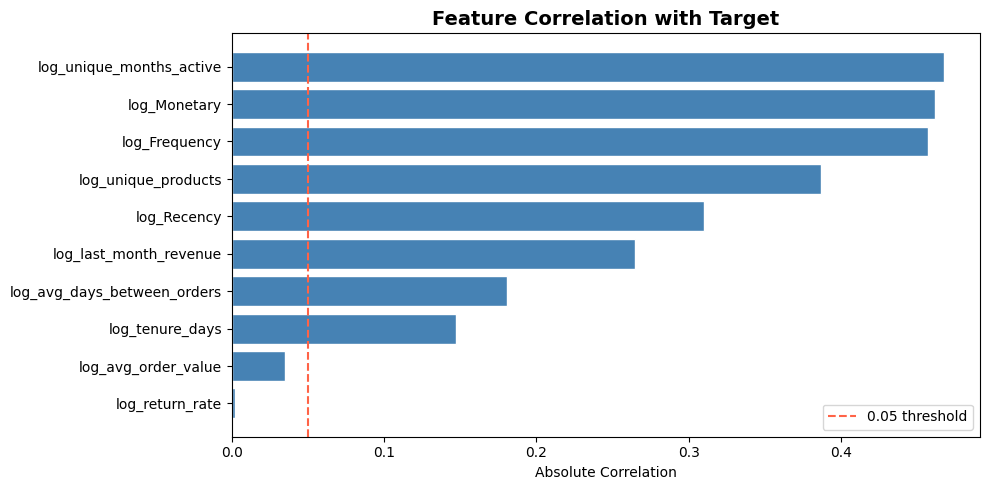

In [10]:
plt.figure(figsize=(10,5))
plt.barh(target_corr["Feature"],
         target_corr["Correlation with Target"],
         color="steelblue",
         edgecolor="white")
plt.title('Feature Correlation with Target',
          fontsize=14,
          fontweight='bold')
plt.gca().invert_yaxis()
plt.axvline(x=0.05, color="tomato",
            linestyle="--", label='0.05 threshold')
plt.xlabel('Absolute Correlation')
plt.legend()
plt.tight_layout()
plt.show()

The top three features, log_unique_months_active, log_Monetary, and log_Frequency are all sitting close together around 0.46, so no single feature is dominating. log_return_rate and log_avg_order_value are weak but we'll let the mutual information scores have the final say.

### **Mutual Information**

In [11]:
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_df = pd.DataFrame({
    "Feature": feature_cols,
    "Mutual Information": mi_scores
}).sort_values("Mutual Information", ascending=False).reset_index(drop=True)

In [12]:
mi_df

,Feature,Mutual Information
0,log_Monetary,0.284438
1,log_unique_months_active,0.179279
2,log_Frequency,0.166448
3,log_unique_products,0.111637
4,log_avg_days_between_orders,0.106278
5,log_last_month_revenue,0.094438
6,log_return_rate,0.064947
7,log_Recency,0.060231
8,log_avg_order_value,0.051480
9,log_tenure_days,0.038816


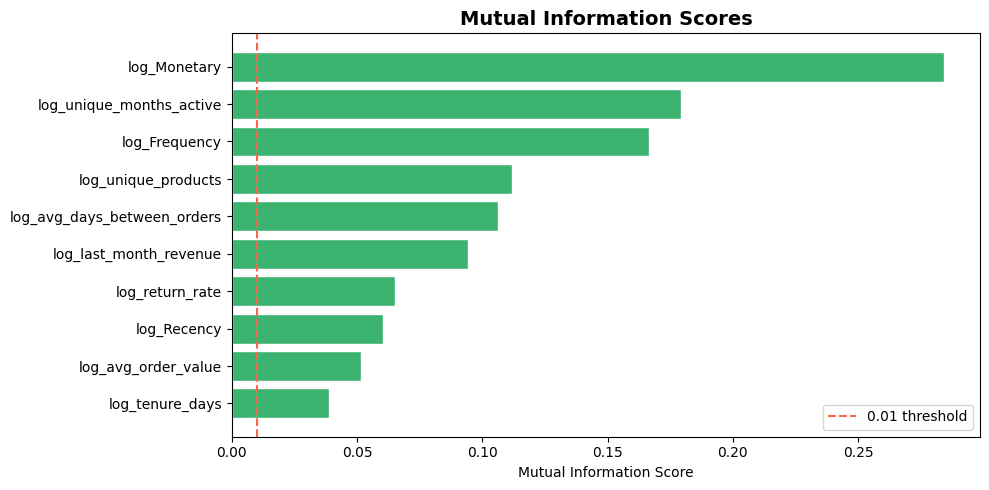

In [13]:
# Plot
plt.figure(figsize=(10,5))
plt.barh(mi_df["Feature"],
         mi_df["Mutual Information"],
         color="mediumseagreen", edgecolor="white")
plt.gca().invert_yaxis()
plt.axvline(x=0.01, color="tomato", linestyle="--", label="0.01 threshold")
plt.title("Mutual Information Scores", fontsize=14, fontweight="bold")
plt.xlabel('Mutual Information Score')
plt.legend()
plt.tight_layout()
plt.show()

### **Drop Weak Features**

In [14]:
summary = target_corr.merge(mi_df, on="Feature")
summary

,Feature,Correlation with Target,Mutual Information
0,log_unique_months_active,0.468,0.179279
1,log_Monetary,0.462,0.284438
2,log_Frequency,0.457,0.166448
3,log_unique_products,0.387,0.111637
4,log_Recency,0.310,0.060231
5,log_last_month_revenue,0.265,0.094438
6,log_avg_days_between_orders,0.181,0.106278
7,log_tenure_days,0.147,0.038816
8,log_avg_order_value,0.035,0.051480
9,log_return_rate,0.002,0.064947


In [15]:
summary = summary.sort_values("Mutual Information", ascending=False)
summary

,Feature,Correlation with Target,Mutual Information
1,log_Monetary,0.462,0.284438
0,log_unique_months_active,0.468,0.179279
2,log_Frequency,0.457,0.166448
3,log_unique_products,0.387,0.111637
6,log_avg_days_between_orders,0.181,0.106278
5,log_last_month_revenue,0.265,0.094438
9,log_return_rate,0.002,0.064947
4,log_Recency,0.310,0.060231
8,log_avg_order_value,0.035,0.051480
7,log_tenure_days,0.147,0.038816


In [16]:
weak_features = summary[
    (summary["Correlation with Target"] < 0.05) &
    (summary["Mutual Information"] < 0.01)
]["Feature"].tolist()
print(f"Features flagged as weak: {weak_features}")

Features flagged as weak: []


No features was flagged, so we're keeping all ten. Every feature showed at least some relationship with the target, either through correlation, mutual information, or both. Log_return_rate and log_tenure_days which look weak have signals that is important for our analysis.